# Attention — From Scratch (NumPy only)

**Read `README.md` first.** Every block cites the section (§) it implements.

Lesson 12 ended with two complaints: the bottleneck (the whole past in 24 numbers) and the sequential tax. This lesson answers both with one mechanism — and Block 6 is the LAST backward pass you will ever need to derive by hand: after it, you've differentiated every operation inside a transformer.

In [1]:
# Block 1 — Imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

np.random.seed(113)

## Block 2 — Two tasks, one continuity table *(README §1)*

Task 1 is lesson 12's recall, VERBATIM protocol (T=50, same generator recipe): remember the first token past 49 identical distractors. The scoreboard so far — vanilla RNN: a lottery at this distance; LSTM: 100% via the belt. Task 2 removes the positional shortcut: four (letter,digit) pairs in random order + a query letter; the answer's position changes every sequence.

In [2]:
rec = pd.read_csv("data/recall_data.csv")
tok1 = np.array([[0 if ch == "A" else 1 for ch in s] for s in rec.sequence])
y1 = (rec.label == "B").astype(int).values
print(f"task 1 (recall): {tok1.shape[0]} sequences, T={tok1.shape[1]}  — lesson 12's exam, resat")

kv = pd.read_csv("data/kv_data.csv")
LETTERS = list("ABCDEF")
PAIRS = {f"{L}{v}": i for i, (L, v) in enumerate((L, v) for L in LETTERS for v in range(10))}
QTOK = {L: 60 + i for i, L in enumerate(LETTERS)}
tok2 = np.array([[PAIRS[s[i:i+2]] for i in range(0, 8, 2)] + [QTOK[s[8]]] for s in kv.sequence])
y2 = kv.answer.values
print(f"task 2 (key-value): {tok2.shape[0]} sequences, T=5, vocab 66")
print(f"example: {kv.sequence.iloc[0]!r} -> answer {y2[0]}   (find the pair matching the last letter; report its digit)")

task 1 (recall): 1600 sequences, T=50  — lesson 12's exam, resat
task 2 (key-value): 2400 sequences, T=5, vocab 66
example: 'C2D0F3E2E' -> answer 2   (find the pair matching the last letter; report its digit)


## Block 3 — Embeddings, and the permutation trap *(README §3.4)*

Tokens become learned vectors (an embedding table — lesson 11's shared-weights rule will apply to its gradients too). Then the trap: attention with NO positional information is a SET operation — shuffle the sequence and the final position's output is byte-identical. For 'which token came first?' that's not hard, it's IMPOSSIBLE. The cure: add a learned position vector into each embedding.

In [3]:
def softmax(Z):
    Z = Z - Z.max(axis=-1, keepdims=True)
    e = np.exp(Z)
    return e / e.sum(axis=-1, keepdims=True)

d = 24
rs = np.random.default_rng(0)
E_demo  = rs.normal(0, 0.3, (2, d))          # embeddings for tokens A/B
Wq = rs.normal(0, 0.3, (d, d)); Wk = rs.normal(0, 0.3, (d, d)); Wv = rs.normal(0, 0.3, (d, d))

def attend_last(X):
    Q = X @ Wq; K = X @ Wk; V = X @ Wv
    A = softmax(Q @ K.transpose(0, 2, 1) / np.sqrt(d))
    return (A @ V)[:, -1, :]                  # the final position's context vector

seq = tok1[:1]                                 # one sequence
perm = np.random.permutation(49)               # shuffle everything EXCEPT the final position
seq_shuf = seq.copy(); seq_shuf[0, :49] = seq[0, perm]

out_plain      = attend_last(E_demo[seq])
out_plain_shuf = attend_last(E_demo[seq_shuf])
print(f"NO positions — output difference under shuffle: {np.abs(out_plain - out_plain_shuf).max():.2e}")
print("Byte-identical: the model literally cannot know who was first (README §3.4).\n")

Pos = rs.normal(0, 0.3, (50, d))
out_pos      = attend_last(E_demo[seq]      + Pos[None])
out_pos_shuf = attend_last(E_demo[seq_shuf] + Pos[None])
print(f"WITH positions — output difference under shuffle: {np.abs(out_pos - out_pos_shuf).max():.2e}")
print("Order now exists, because position is part of what each key ADVERTISES.")

NO positions — output difference under shuffle: 1.94e-16
Byte-identical: the model literally cannot know who was first (README §3.4).

WITH positions — output difference under shuffle: 1.83e-02
Order now exists, because position is part of what each key ADVERTISES.


## Block 4 — The forward pass: six lines *(README §3.1–3.2)*

Three projections (the same vectors in three costumes: question / spine / contents), a T×T score table, a softmax budget per query, and the value-blend payout. Every position attends simultaneously — nothing waits for anything.

In [4]:
def init_attn(vocab, T, d=24, n_out=2, seed=0):
    rs = np.random.default_rng(seed)
    s = 0.3
    return {"E": rs.normal(0, s, (vocab, d)), "Pos": rs.normal(0, s, (T, d)),
            "Wq": rs.normal(0, s, (d, d)), "Wk": rs.normal(0, s, (d, d)), "Wv": rs.normal(0, s, (d, d)),
            "W1": rs.normal(0, s, (d, 32)), "b1": np.zeros(32),
            "W2": rs.normal(0, s, (32, n_out)), "b2": np.zeros(n_out)}

def attn_forward(P, tok):
    """README §3.1–3.2 — the whole mechanism."""
    m, T = tok.shape; d = P["E"].shape[1]
    X = P["E"][tok] + P["Pos"][None, :T, :]           # content + position (§3.4)
    Q = X @ P["Wq"]; K = X @ P["Wk"]; V = X @ P["Wv"] # three costumes (§3.1)
    S = Q @ K.transpose(0, 2, 1) / np.sqrt(d)         # every query scores every key (§3.2)
    A = softmax(S)                                     # each row: a probability BUDGET
    O = A @ V                                          # payout: value-blends
    o_last = O[:, -1, :]                               # we predict from the final position
    H1 = np.maximum(0, o_last @ P["W1"] + P["b1"])
    Pr = softmax(H1 @ P["W2"] + P["b2"])
    return Pr, (X, Q, K, V, S, A, O, o_last, H1)

P_demo = init_attn(2, 50)
Pr, cache = attn_forward(P_demo, tok1[:4])
print("shapes — X:", cache[0].shape, " scores:", cache[4].shape, " budgets A:", cache[5].shape, " outputs:", Pr.shape)
print(f"each budget row sums to 1: {cache[5][0, -1].sum():.6f}")

shapes — X: (4, 50, 24)  scores: (4, 50, 50)  budgets A: (4, 50, 50)  outputs: (4, 2)
each budget row sums to 1: 1.000000


## Block 5 — The √d experiment, measured *(README §3.3)*

Dot products of d-vectors have variance ≈ d (the d terms' variances ADD — the same additivity behind lesson 06's √B). Unscaled scores explode with width, softmax saturates toward one-hot, and its gradient dies — lesson 10's sleeping neurons, attention edition.

In [5]:
rs = np.random.default_rng(1)
print(f"{'d':>5} {'std(q·k)':>10} {'std(q·k/√d)':>12} {'softmax max wt':>15} {'grad norm':>10}")
for dd in [4, 16, 64, 256]:
    q = rs.normal(0, 1, (4000, dd)); k = rs.normal(0, 1, (4000, dd))
    raw = (q*k).sum(1)
    S_raw = rs.normal(0, raw.std(), (400, 16))
    A_raw = softmax(S_raw)
    grad = (A_raw * (1 - A_raw)).mean()                # the diagonal of softmax's Jacobian
    print(f"{dd:>5} {raw.std():>10.2f} {(raw/np.sqrt(dd)).std():>12.2f} {A_raw.max(1).mean():>15.2f} {grad:>10.4f}")
print()
print("Down the table: unscaled scores grow like √d, budgets collapse to one-hot, gradients")
print("head to zero. The /√d keeps every column healthy at any width (README §3.3, fig 04).")

    d   std(q·k)  std(q·k/√d)  softmax max wt  grad norm
    4       1.97         0.99            0.46     0.0427
   16       4.03         1.01            0.68     0.0271
   64       8.03         1.00            0.85     0.0136


  256      15.59         0.97            0.92     0.0070

Down the table: unscaled scores grow like √d, budgets collapse to one-hot, gradients
head to zero. The /√d keeps every column healthy at any width (README §3.3, fig 04).


## Block 6 — The last hand-built backward pass *(README §3.5)*

Every line is machinery you own: matmul gradients (lesson 10), the softmax row-Jacobian (same algebra as lesson 11's head), ReLU's gate, and embedding gradients as scatter-adds (lesson 11's sharing = summing, vocabulary edition). Then the numerical check. After this cell, you have personally differentiated every operation inside a transformer.

In [6]:
def attn_backward(P, tok, y, Pr, cache):
    """README §3.5."""
    X, Q, K, V, S, A, O, o_last, H1 = cache
    m, T = tok.shape; d = P["E"].shape[1]
    G = {k: np.zeros_like(v) for k, v in P.items()}
    n_out = Pr.shape[1]
    d_log = (Pr - np.eye(n_out)[y]) / m               # guess − truth: the miracle's 4th appearance
    G["W2"] = H1.T @ d_log; G["b2"] = d_log.sum(0)
    dH1 = (d_log @ P["W2"].T) * (H1 > 0)              # ReLU's gate
    G["W1"] = o_last.T @ dH1; G["b1"] = dH1.sum(0)
    dO = np.zeros_like(O)
    dO[:, -1, :] = dH1 @ P["W1"].T                    # only the final position fed the head
    dA = dO @ V.transpose(0, 2, 1)                    # blame for the budgets
    dV = A.transpose(0, 2, 1) @ dO                    # blame for the contents
    dS = A * (dA - (dA * A).sum(-1, keepdims=True))   # softmax row-Jacobian (lesson 11's algebra)
    dS = dS / np.sqrt(d)
    dQ = dS @ K                                        # blame flows to questions...
    dK = dS.transpose(0, 2, 1) @ Q                    # ...and to the spines they matched
    dX = dQ @ P["Wq"].T + dK @ P["Wk"].T + dV @ P["Wv"].T
    G["Wq"] = np.einsum("mtd,mte->de", X, dQ)
    G["Wk"] = np.einsum("mtd,mte->de", X, dK)
    G["Wv"] = np.einsum("mtd,mte->de", X, dV)
    G["Pos"][:T] = dX.sum(0)                          # every sequence used the same Pos rows
    np.add.at(G["E"], tok, dX)                        # a shared embedding collects blame everywhere
    return G

def ce(Pr, y): return -np.mean(np.log(Pr[np.arange(len(y)), y] + 1e-12))

P = init_attn(2, 50, seed=1)
sub, ysub = tok1[:64], y1[:64]
Pr, cache = attn_forward(P, sub)
G = attn_backward(P, sub, ysub, Pr, cache)
eps = 1e-5
P["Wq"][3, 5] += eps; Lu = ce(attn_forward(P, sub)[0], ysub)
P["Wq"][3, 5] -= 2*eps; Ld = ce(attn_forward(P, sub)[0], ysub)
P["Wq"][3, 5] += eps
print(f"analytic dL/dWq[3,5]: {G['Wq'][3,5]:+.7f}")
print(f"numerical           : {(Lu-Ld)/(2*eps):+.7f}   <- the whole chain (softmax Jacobian included) is right")

analytic dL/dWq[3,5]: -0.0006921
numerical           : -0.0006921   <- the whole chain (softmax Jacobian included) is right


## Block 7 — Train on lesson 12's exam + read the strategy + one confession *(README §2.3 + §6)*

The scoreboard completes. Then the confession: our positional table has exactly 50 rows — feed a length-80 sequence and row 51 does not exist. Lesson 12's RNN generalized across lengths for free; learned-position attention does not. Every architecture pays somewhere.

In [7]:
class Adam:
    def __init__(self, P, lr):
        self.m = {k: np.zeros_like(v) for k, v in P.items()}
        self.v = {k: np.zeros_like(v) for k, v in P.items()}
        self.lr, self.t = lr, 0
    def step(self, P, G):
        self.t += 1
        for k in P:
            self.m[k] = 0.9*self.m[k] + 0.1*G[k]
            self.v[k] = 0.999*self.v[k] + 0.001*G[k]**2
            mh = self.m[k]/(1-0.9**self.t); vh = self.v[k]/(1-0.999**self.t)
            P[k] -= self.lr * mh/(np.sqrt(vh)+1e-8)

def train_attn(tok, y, vocab, n_out, T=None, epochs=15, lr=3e-3, batch=128, seed=0, snap_A=None):
    T = T or tok.shape[1]
    P = init_attn(vocab, T, n_out=n_out, seed=seed)
    opt = Adam(P, lr)
    rs = np.random.default_rng(seed)
    snaps = []
    for ep in range(epochs):
        order = rs.permutation(len(y))
        for s_ in range(0, len(y), batch):
            b = order[s_:s_+batch]
            Pr, cache = attn_forward(P, tok[b])
            G = attn_backward(P, tok[b], y[b], Pr, cache)
            opt.step(P, G)
        if snap_A is not None:
            snaps.append(attn_forward(P, snap_A)[1][5][:, -1, :].mean(0))   # avg final-row budget
    return P, snaps

idx = np.random.permutation(len(y1)); cut = int(0.8*len(y1))
tr1, te1 = idx[:cut], idx[cut:]
P1, snaps = train_attn(tok1[tr1], y1[tr1], vocab=2, n_out=2, snap_A=tok1[te1][:200])
Pr1, cache1 = attn_forward(P1, tok1[te1])
acc1 = (Pr1.argmax(1) == y1[te1]).mean()
budget0 = cache1[5][:, -1, 0].mean()
print(f"SCOREBOARD, recall at T=50 — vanilla RNN: lottery (lesson 12) | LSTM: 100% via the belt | attention: {acc1:.0%}")
print(f"the strategy: {budget0:.0%} of the final position's budget goes to position 0 — one learned lookup.\n")

try:
    long_seq = np.random.default_rng(5).integers(0, 2, (1, 80))
    attn_forward(P1, long_seq)
except Exception as e:
    print(f"length-80 sequence -> {type(e).__name__}: positional row 51+ does not exist.")
print("The confession (README §6): learned positions stop at the training length. Lesson 12's")
print("RNN ran to T=80 for free; here that freedom must be re-purchased (sinusoidal/relative")
print("encodings — the production answer). Every architecture pays somewhere.")

SCOREBOARD, recall at T=50 — vanilla RNN: lottery (lesson 12) | LSTM: 100% via the belt | attention: 100%
the strategy: 98% of the final position's budget goes to position 0 — one learned lookup.

length-80 sequence -> ValueError: positional row 51+ does not exist.
The confession (README §6): learned positions stop at the training length. Lesson 12's
RNN ran to T=80 for free; here that freedom must be re-purchased (sinusoidal/relative
encodings — the production answer). Every architecture pays somewhere.


## Block 8 — Watch the strategy get discovered *(README §5)*

Per-epoch snapshots of the final position's average budget: it starts near-uniform (attend to everything, know nothing) and sharpens into a spike at position 0. Strategy formation, visible.

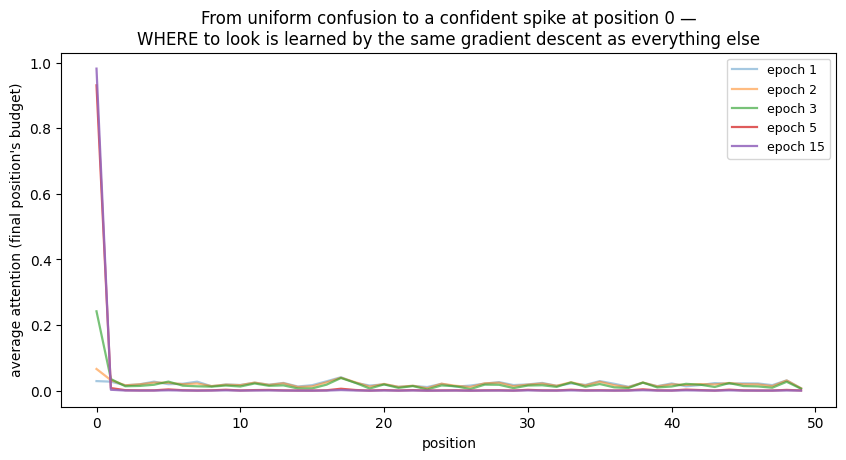

budget entropy per epoch: 3.86 -> 3.83 -> 3.42 -> 1.56 -> 0.49 -> 0.25 ... final 0.15
(uniform over 50 positions would be 3.91; a pure one-hot would be 0.00)


In [8]:
fig, ax = plt.subplots(figsize=(10, 4.6))
show = [0, 1, 2, 4, len(snaps)-1]
for i, ep in enumerate(show):
    ax.plot(snaps[ep], lw=1.6, alpha=0.4 + 0.6*i/len(show), label=f"epoch {ep+1}")
ax.set_xlabel("position"); ax.set_ylabel("average attention (final position's budget)")
ax.legend(fontsize=9)
ax.set_title("From uniform confusion to a confident spike at position 0 —\nWHERE to look is learned by the same gradient descent as everything else")
plt.show()

ent = [-np.sum(s * np.log(s + 1e-12)) for s in snaps]
print("budget entropy per epoch:", " -> ".join(f"{e:.2f}" for e in ent[:6]), f"... final {ent[-1]:.2f}")
print(f"(uniform over 50 positions would be {np.log(50):.2f}; a pure one-hot would be 0.00)")

## Block 9 — Task 2: take away the positional shortcut *(README §2.5)*

Recall could be solved by position alone ('look at slot 0'). Here the matching pair sits at a DIFFERENT position every sequence: the lookup address must be computed from CONTENT. This is the capability no earlier architecture had — and the mechanism behind a pronoun finding its referent.

key-value retrieval test accuracy: 100%



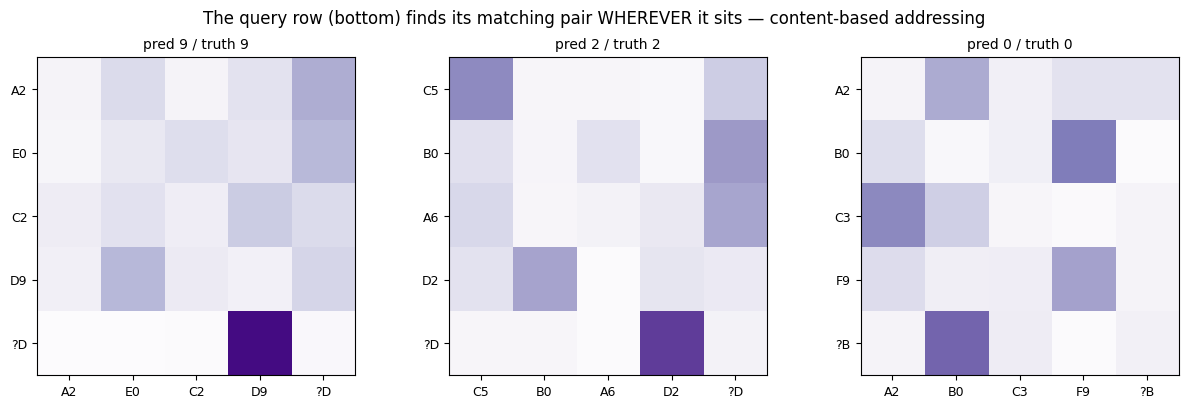

In [9]:
idx2 = np.random.permutation(len(y2)); cut2 = int(0.8*len(y2))
tr2, te2 = idx2[:cut2], idx2[cut2:]
P2, _ = train_attn(tok2[tr2], y2[tr2], vocab=66, n_out=10, epochs=40, seed=0)
Pr2, cache2 = attn_forward(P2, tok2[te2])
acc2 = (Pr2.argmax(1) == y2[te2]).mean()
print(f"key-value retrieval test accuracy: {acc2:.0%}\n")

inv_pairs = {v: k for k, v in {f"{L}{v}": i for i, (L, v) in enumerate((L, v) for L in LETTERS for v in range(10))}.items()}
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4))
for ax, ei in zip(axes, range(3)):
    t = tok2[te2][ei]
    names = [inv_pairs[x] if x < 60 else "?" + LETTERS[x-60] for x in t]
    ax.imshow(cache2[5][ei], cmap="Purples", vmin=0, vmax=1)
    ax.set_xticks(range(5)); ax.set_xticklabels(names, fontsize=9)
    ax.set_yticks(range(5)); ax.set_yticklabels(names, fontsize=9)
    ax.set_title(f"pred {Pr2[ei].argmax()} / truth {y2[te2][ei]}", fontsize=10)
plt.suptitle("The query row (bottom) finds its matching pair WHEREVER it sits — content-based addressing")
plt.tight_layout(); plt.show()

## Block 10 — The tax refunded, and the new bill *(README §6)*

(a) Wall-clock — and a measurement that will surprise you, then teach you the real lesson about WHERE attention's speed lives. (b) The invoice: the score table is T×T — quadratic. Both measured; know what you're buying and what it costs.

In [10]:
# (a) a same-budget RNN forward (H=24) vs our attention forward, same batch
def rnn_forward_time(Xs, H=24):
    rs = np.random.default_rng(0)
    Wx = rs.normal(0, .3, (Xs.shape[2], H)); Wh = rs.normal(0, .3, (H, H)); b = np.zeros(H)
    h = np.zeros((Xs.shape[0], H))
    for t in range(Xs.shape[1]):
        h = np.tanh(Xs[:, t] @ Wx + h @ Wh + b)      # step t+1 CANNOT start before step t
    return h

X1h = np.eye(2)[tok1[:512]]
t0 = time.time(); rnn_forward_time(X1h); t_rnn = time.time() - t0
t0 = time.time(); attn_forward(P1, tok1[:512]); t_attn = time.time() - t0
print(f"forward pass, 512 sequences of T=50 — RNN loop: {t_rnn*1000:.0f} ms | attention: {t_attn*1000:.0f} ms")
print()
print("Read that honestly: on CPU at this scale, attention LOSES — it simply does more")
print("arithmetic (O(T²·d) vs the RNN's O(T·d²); here 50×50 score tables dwarf 50 tiny steps).")
print("So where's the refund? In the DEPENDENCY STRUCTURE, not the op count: the RNN's 50")
print("steps form a serial chain — no hardware can start step 31 before step 30 — while")
print("attention's entire computation is dependency-free across positions: one shot of")
print("matmuls, arbitrarily parallelizable. Wide hardware (GPUs/TPUs) monetizes exactly that:")
print("serial DEPTH becomes the bottleneck, and attention's depth is 1 vs the RNN's T.")
print("More work, better-shaped work — that trade built the transformer era.\n")

# (b) the invoice
print(f"{'T':>8} {'score-table entries (T², one layer, one head)':>46}")
for T in [50, 1000, 10000, 100000]:
    print(f"{T:>8} {T*T:>46,}")
print("\nKilling the bottleneck bought direct access to everything — priced at everything×everything.")
print("The engineering of the modern era (KV-caches, sparse/linear attention, chunking) is a")
print("campaign against this exact table. Lesson 14 stacks the block anyway — the trade was worth it.")

forward pass, 512 sequences of T=50 — RNN loop: 4 ms | attention: 251 ms

Read that honestly: on CPU at this scale, attention LOSES — it simply does more
arithmetic (O(T²·d) vs the RNN's O(T·d²); here 50×50 score tables dwarf 50 tiny steps).
So where's the refund? In the DEPENDENCY STRUCTURE, not the op count: the RNN's 50
steps form a serial chain — no hardware can start step 31 before step 30 — while
attention's entire computation is dependency-free across positions: one shot of
matmuls, arbitrarily parallelizable. Wide hardware (GPUs/TPUs) monetizes exactly that:
serial DEPTH becomes the bottleneck, and attention's depth is 1 vs the RNN's T.
More work, better-shaped work — that trade built the transformer era.

       T  score-table entries (T², one layer, one head)
      50                                          2,500
    1000                                      1,000,000
   10000                                    100,000,000
  100000                                 10,000,000,

---
## What you now own

- The lookup: Q/K/V as question/spine/contents, softmax budgets, value-blends — six lines forward
- The √d as measured anti-saturation medicine, and the permutation trap with its positional cure
- The course's last hand-derived backward pass — you have now differentiated everything in a transformer
- Two strategies read off attention maps: a positional lookup (94% on slot 0) and content-based addressing (the pair found wherever it hides)
- The honest ledger: bottleneck killed, tax refunded, T² invoiced, learned positions capped at T=50

**Next:** `attention_with_library.ipynb` — then folder `14-transformers`: heads, stacks, residuals, masks. The assembly.